In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib.ticker as mticker
from scipy.integrate import quad
from scipy.optimize import root_scalar
import math 
from numba import jit

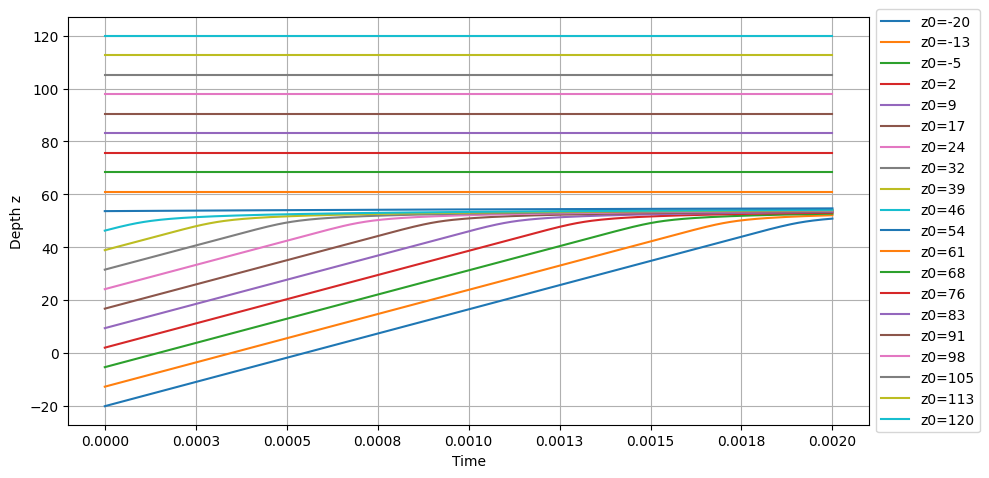

In [22]:

# Velocity function 
def u(z):
    return 1e-2 + 3.66e4 / (1 + np.exp((z - 50)))  # smoother transition

# Time span
t_span = (0, 0.002)   # keep small due to large velocity
t_eval = np.linspace(*t_span, 300)

# Initial depths (characteristics start here)
z0_values = np.linspace(-20, 120, 20)

characteristics = {}

plt.figure(figsize=(10, 5))

for z0 in z0_values:
    sol = solve_ivp(
        lambda t, z: [u(z[0])],
        t_span,
        [z0],
        t_eval=t_eval,
        dense_output=True,
        method="Radau"
    )
    z_of_s = lambda s: sol.sol(s)[0]
    characteristics[z0] = z_of_s

    plt.plot(sol.t, sol.y[0], label=f"z0={z0:.0f}")

plt.xlabel("Time")
plt.ylabel("Depth z")
#plt.title("Characteristic curves z(t)")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.grid()
plt.gca().xaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

plt.show()

In [25]:

# -------------------------------------------------
# parameters
# -------------------------------------------------

alpha = 1.74
Da = 1
kappa = 1.42e-2

lambda_ = np.sqrt(alpha / Da)

# -------------------------------------------------
# velocity
# NO /10
# -------------------------------------------------

def u(z):
    return 1e-2 + 3.66e4 / (1 + np.exp(z - 50))

# -------------------------------------------------
# derivative
# consistent with NO /10
# -------------------------------------------------

def du_dz(z):

    exp_term = np.exp(z - 50)

    return -3.66e4 * exp_term / (1 + exp_term)**2

# -------------------------------------------------
# attenuation coefficient
# -------------------------------------------------

def b(z):
    return kappa + du_dz(z)

# -------------------------------------------------
# characteristic travel-time integral
#
# t - s = ∫ dz/u(z)
# -------------------------------------------------

def travel_time(z1, z2):

    val, _ = quad(
        lambda zeta: 1 / u(zeta),
        z1,
        z2
    )

    return val

# -------------------------------------------------
# characteristic z(s; z,t)
#
# implicitly solve:
#
# t - s = ∫_{z(s)}^z dζ/u(ζ)
# -------------------------------------------------

def z_of_s(s, z, t):

    target = t - s

    def F(zs):

        return (
            travel_time(zs, z)
            - target
        )

    sol = root_scalar(
        F,
        bracket=[0, z],
        method='bisect'
    )

    return sol.root

# -------------------------------------------------
# boundary hitting time
#
# τ(z,t)=t-∫₀ᶻ dζ/u(ζ)
# -------------------------------------------------

def tau(z, t):

    return (
        t
        - travel_time(0, z)
    )

# -------------------------------------------------
# lower integration limit
#
# piecewise:
#
# if τ>0:
#     BC region
#
# else:
#     IC region
# -------------------------------------------------

def t0(z, t):

    tau_val = tau(z, t)

    return max(0.0, tau_val)

# -------------------------------------------------
# integrand
# -------------------------------------------------

def integrand(s, z, t):

    z_s = z_of_s(s, z, t)

    attenuation, _ = quad(
        lambda xi: b(z_of_s(xi, z, t)),
        s,
        t
    )

    return (
        alpha
        * np.exp(-lambda_ * z_s)
        * np.exp(-attenuation)
    )

# -------------------------------------------------
# piecewise characteristic solution
# -------------------------------------------------

def B(z, t):

    lower = t0(z, t)

    result, _ = quad(
        integrand,
        lower,
        t,
        args=(z, t)
    )

    return result



In [ ]:
# -------------------------------------------------# plotting# -------------------------------------------------
z_grid = np.linspace(0, 150, 120)
times_to_plot = [0,0.0002, 0.0005,0.001, 0.005,0.01]
plt.figure(figsize=(12,6))
for t in times_to_plot:    
    B_vals = []    
    for z in z_grid:        
        B_vals.append(B(z, t))    
    plt.plot(B_vals,z_grid,label=f"t = {t:.4f}")
# seabed
plt.axhline(    y=50,    linestyle='--',    label='Seabed')
# depth increasing downward
plt.gca().invert_yaxis()
plt.xlabel("Concentration")
plt.ylabel("Depth z")
plt.legend(    loc="center left",    bbox_to_anchor=(1, 0.5))
plt.grid()
plt.tight_layout()
plt.show()

Comparing to numerical solver

In [34]:
@jit
def b_solver(b, alpha, kappa, A_st1,dz,time_steps,u,dt):
    inv_dz = 1.0 / dz
    for i in range(time_steps): # lopping over time steps
        b_new1 = b.copy()
        U_face_prev = 0.5 * (u[0] + u[1])
        B_face_prev = (b[0] if U_face_prev >= 0.0 else b[1])
        F_prev = U_face_prev * B_face_prev
        for j in range(1, Nx-1): # looping over spatial steps
            U1_face_curr = 0.5 * (u[j] + u[j+1])
            B1_face_curr = (b[j] if U1_face_curr >= 0.0 else b[j+1])
            F1_curr = U1_face_curr * B1_face_curr

            # Conservative advection at cell j: -(F_{j+1/2} - F_{j-1/2})/dz
            adv = -(F1_curr - F_prev) * inv_dz

            b_new1[j] = b[j] + dt*(adv+ alpha*A_st1[j]- kappa*b[j])
            F_prev = F1_curr
        b_new1[0] = b_new1[1] # boundary condition at z=0
        b_new1[-1] = 0 # boundary condition at z=L
        b = b_new1.copy() # update b for the next time step
    return b

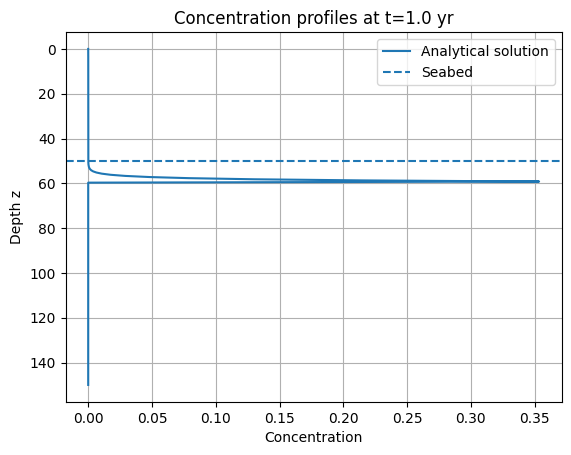

In [29]:
#plt.plot(b_val, z, label="Numerical solver")
plt.plot(B_vals,z_grid,label="Analytical solution")
plt.axhline(    y=50,    linestyle='--',    label='Seabed')
plt.gca().invert_yaxis()
plt.xlabel("Concentration")
plt.ylabel("Depth z")
plt.title("Concentration profiles at t={:.1f} yr".format(t_final[0]))
plt.legend()
plt.grid()
plt.show()

after 70 years, what is peak concentration?

In [23]:
@jit
def b_solver(b, alpha, kappa, A_st1,dz,time_steps,u,dt,Nx):
    inv_dz = 1.0 / dz
    for i in range(time_steps): # lopping over time steps
        b_new1 = b.copy()
        U_face_prev = 0.5 * (u[0] + u[1])
        B_face_prev = (b[0] if U_face_prev >= 0.0 else b[1])
        F_prev = U_face_prev * B_face_prev
        for j in range(1, Nx-1): # looping over spatial steps
            U1_face_curr = 0.5 * (u[j] + u[j+1])
            B1_face_curr = (b[j] if U1_face_curr >= 0.0 else b[j+1])
            F1_curr = U1_face_curr * B1_face_curr

            # Conservative advection at cell j: -(F_{j+1/2} - F_{j-1/2})/dz
            adv = -(F1_curr - F_prev) * inv_dz

            b_new1[j] = b[j] + dt*(adv+ alpha*A_st1[j]- kappa*b[j])
            F_prev = F1_curr
        b_new1[0] = b_new1[1] # boundary condition at z=0
        b_new1[-1] = 0 # boundary condition at z=L
        b = b_new1.copy() # update b for the next time step
    return b

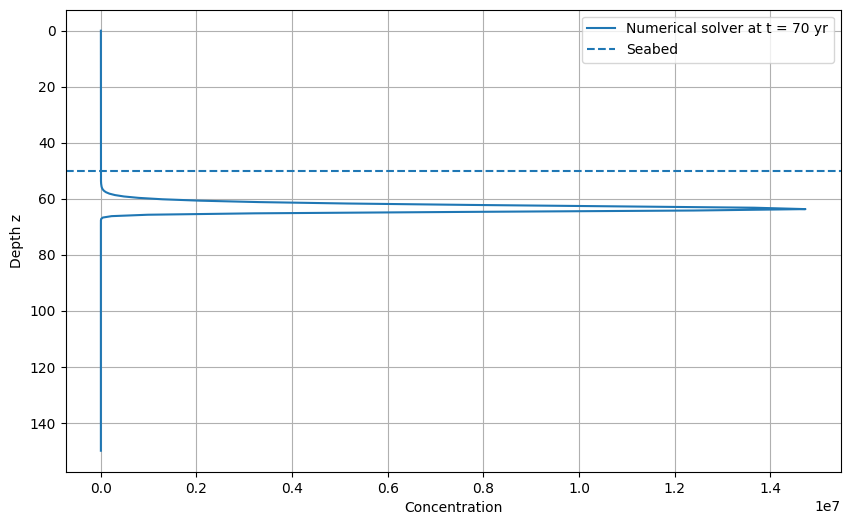

In [16]:
alpha = 1.74
Da = 1
kappa = 1.42e-2

lambda_ = np.sqrt(alpha / Da)
z = np.linspace(0, 150, 300)
A_st = np.exp(-lambda_ * z)
u = 10**(-2)+(3.66*10**4)/(1+np.exp(z-50))
t_final = 70
Dz = z[1] - z[0]
Nx = len(z)
dt = 0.5 * Dz / np.max(np.abs(u))
time_steps = math.ceil(t_final / dt)
dt = t_final / time_steps  # end exactly at t_final

b = np.zeros_like(z)
b = b_solver(b, alpha, kappa, A_st, Dz,time_steps,u,dt,Nx)

plt.figure(figsize=(10,6))

plt.plot(b, z, label="Numerical solver at t = 70 yr")
# seabed
plt.axhline(    y=50,    linestyle='--',    label='Seabed')
# depth increasing downward
plt.gca().invert_yaxis()
plt.xlabel("Concentration")
plt.ylabel("Depth z")
plt.legend()
plt.grid()
plt.show()

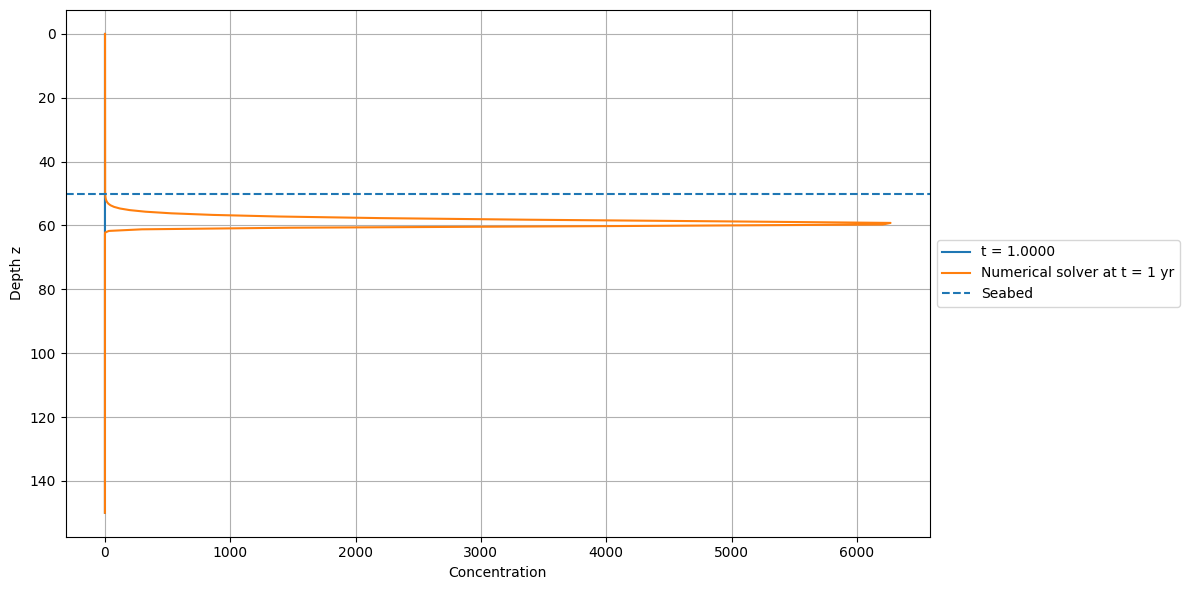

In [ ]:
alpha = 1.74
Da = 1
kappa = 1.42e-2

lambda_ = np.sqrt(alpha / Da)
z = np.linspace(0, 150, 300)
A_st = np.exp(-lambda_ * z)
u_val = 10**(-2)+(3.66*10**4)/(1+np.exp(z-50))
t_final = 1
Dz = z[1] - z[0]
Nx = len(z)
dt = 0.5 * Dz / np.max(np.abs(u_val))
time_steps = math.ceil(t_final / dt)
dt = t_final / time_steps  # end exactly at t_final

bval = np.zeros_like(z)
bval = b_solver(bval, alpha, kappa, A_st, Dz,time_steps,u_val,dt,Nx)

plt.figure(figsize=(12,6))
t_final = [1]
B_vals = []  
z_grid = np.linspace(0, 150, 300)  
for t in t_final:    
    B_vals = []    
    for zi in z_grid:        
        B_vals.append(B(zi, t))    


 

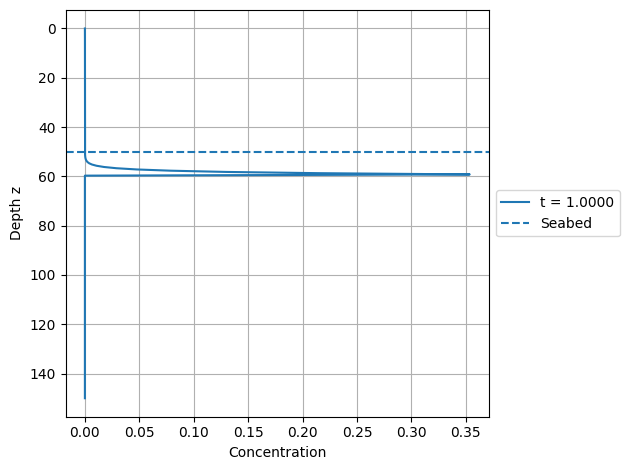

In [28]:
plt.plot(B_vals,z_grid,label=f"t = {t:.4f}")  

#plt.plot(bval, z, label="Numerical solver at t = 1 yr")
# seabed
plt.axhline(    y=50,    linestyle='--',    label='Seabed')
# depth increasing downward
plt.gca().invert_yaxis()
plt.xlabel("Concentration")
plt.ylabel("Depth z")
plt.legend(    loc="center left",    bbox_to_anchor=(1, 0.5))
plt.grid()
plt.tight_layout()
plt.show()